Importing required libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sklearn
import pmdarima
from sktime.forecasting.arima import AutoARIMA, ARIMA
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_correlations
from sktime.performance_metrics.forecasting import mean_absolute_scaled_error,mean_absolute_percentage_error



Reading the data into pandas dataframe and removing null entries
   

In [2]:
data = pd.read_csv('parkingLot.csv')
data = data.dropna()
print(data.shape)

data.head()

(106253, 3)


,vehicle_no,timestamp,camera_id
0,MHUN7063,2024-09-12 05:00:00,1
1,MHYN4677,2024-09-12 05:00:00,1
2,MHEL6595,2024-09-12 05:00:00,1
3,MHNQ2590,2024-09-12 05:00:00,1
4,MHHA0518,2024-09-12 05:00:00,1


In [3]:
entry_data = data[data['camera_id'] == 1]
print(entry_data.shape)

(52976, 3)


In [4]:
# Convert the 'timestamp' column to datetime
entry_data['timestamp'] = pd.to_datetime(entry_data['timestamp'])
print(entry_data.shape)

# Extract the date part from the timestamp and group by the date to count the number of vehicles
cars_per_date = entry_data.groupby(entry_data['timestamp'].dt.date).size().reset_index(name='number_of_cars_entering')

print(cars_per_date)


(52976, 3)
     timestamp  number_of_cars_entering
0   2024-09-12                      886
1   2024-09-13                      809
2   2024-09-14                      861
3   2024-09-15                     1073
4   2024-09-16                      843
..         ...                      ...
58  2024-11-09                      865
59  2024-11-10                      944
60  2024-11-11                      828
61  2024-11-12                      806
62  2024-11-13                      781

[63 rows x 2 columns]


/tmp/ipykernel_62469/2056997998.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entry_data['timestamp'] = pd.to_datetime(entry_data['timestamp'])


<Axes: xlabel='timestamp', ylabel='number_of_cars_entering'>

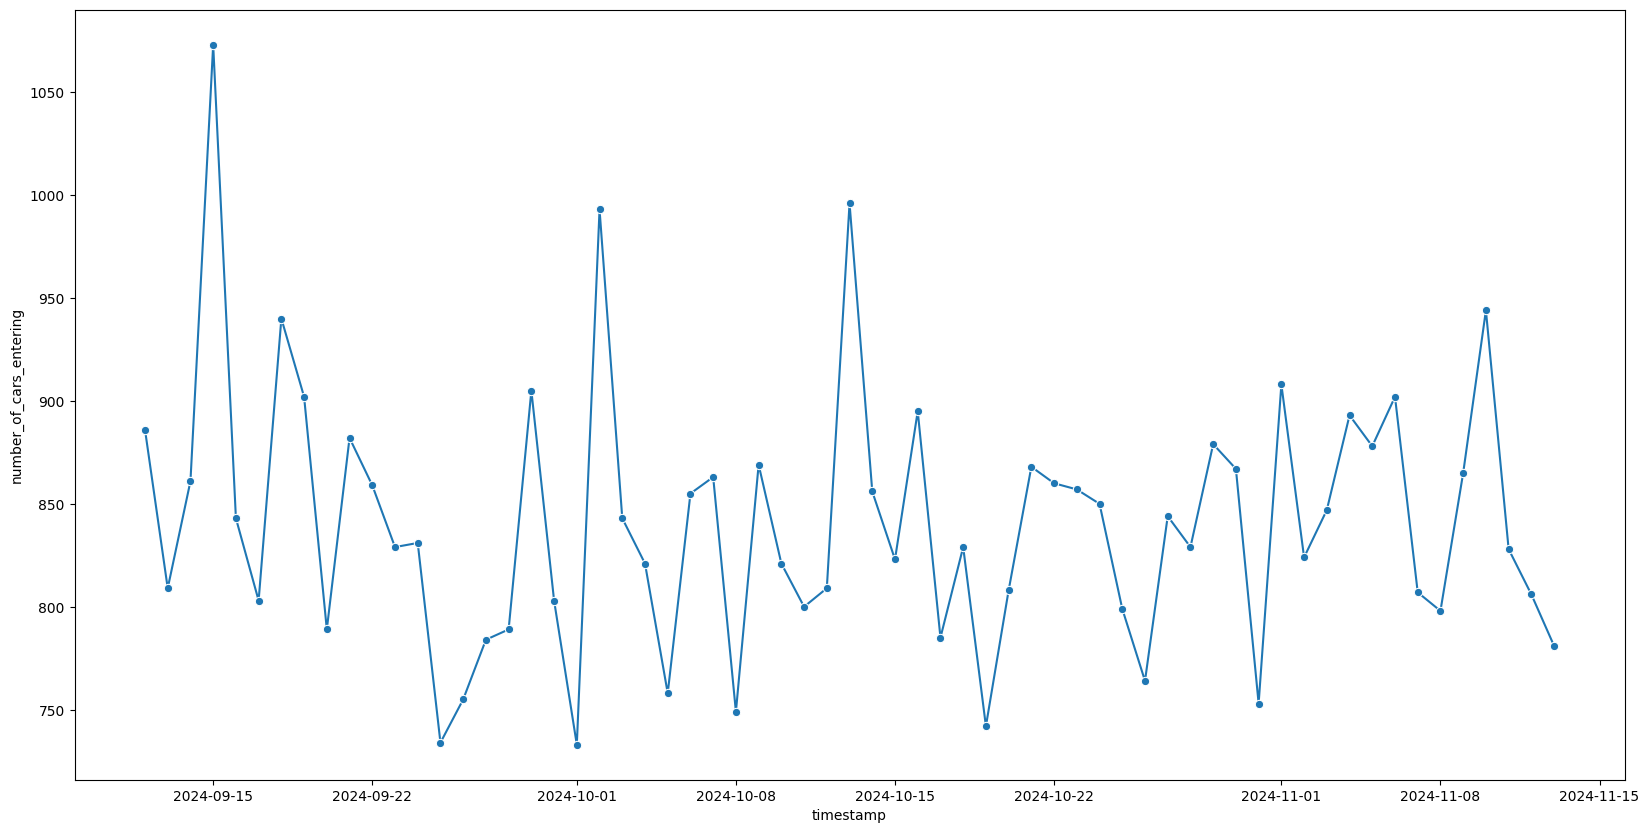

In [5]:
#plotting cars per date
plt.figure(figsize=(20, 10))
sns.lineplot(x='timestamp', y='number_of_cars_entering', data=cars_per_date, marker='o')


Splitting Data into training and testing data

In [6]:
# Splitting the data into training and testing sets
train_data = cars_per_date.iloc[:56]
test_data = cars_per_date.iloc[56:]

print("Training Data:")
print(train_data)
print("\nTesting Data:")
print(test_data)

Training Data:
     timestamp  number_of_cars_entering
0   2024-09-12                      886
1   2024-09-13                      809
2   2024-09-14                      861
3   2024-09-15                     1073
4   2024-09-16                      843
5   2024-09-17                      803
6   2024-09-18                      940
7   2024-09-19                      902
8   2024-09-20                      789
9   2024-09-21                      882
10  2024-09-22                      859
11  2024-09-23                      829
12  2024-09-24                      831
13  2024-09-25                      734
14  2024-09-26                      755
15  2024-09-27                      784
16  2024-09-28                      789
17  2024-09-29                      905
18  2024-09-30                      803
19  2024-10-01                      733
20  2024-10-02                      993
21  2024-10-03                      843
22  2024-10-04                      821
23  2024-10-05           

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='number_of_cars_entering'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

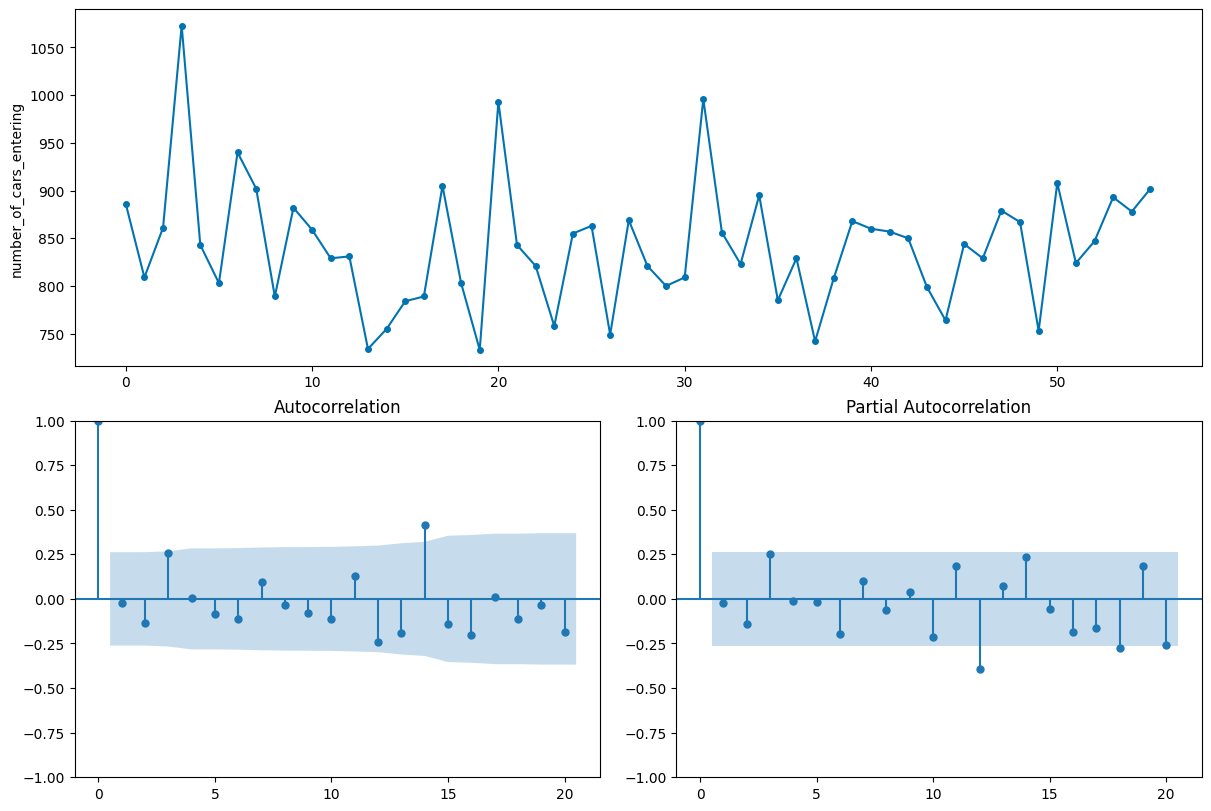

In [7]:
plot_correlations(train_data['number_of_cars_entering'], lags=20)

In [8]:
# forecaster = ARIMA(order=(3, 0, 3), seasonal_order=(1, 0, 1, 14),suppress_warnings=True)
forecaster = AutoARIMA(sp=14,suppress_warnings=True)

forecaster.fit(train_data['number_of_cars_entering'])
forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   SARIMAX Results                                   
=====================================================================================
Dep. Variable:                             y   No. Observations:                   56
Model:             SARIMAX(0, 0, [1, 2], 14)   Log Likelihood                -307.522
Date:                       Sun, 27 Oct 2024   AIC                            623.045
Time:                               01:27:24   BIC                            631.146
Sample:                                    0   HQIC                           626.186
                                        - 56                                         
Covariance Type:                         opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    848.3456     12.578     67.447      0.000     823.693     872.998
ma.S.L14       0.4574      0.170      2.683      0.007       0.123       0.792
ma.S.L28       0.5660      0.329      1.722      0.085      -0.078       1.210
sigma2      2833.8601    955.843      2.965      0.003     960.443    4707.278
===================================================================================
Ljung-Box (L1) (Q):                   0.53   Jarque-Bera (JB):                 5.24
Prob(Q):                              0.47   Prob(JB):                         0.07
Heteroskedasticity (H):               0.43   Skew:                             0.54
Prob(H) (two-sided):                  0.08   Kurtosis:                         4.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

7
56    872.0
57    831.0
58    818.0
59    881.0
60    856.0
61    890.0
62    827.0
Name: number_of_cars_entering, dtype: float64
56    807
57    798
58    865
59    944
60    828
61    806
62    781
Name: number_of_cars_entering, dtype: int64


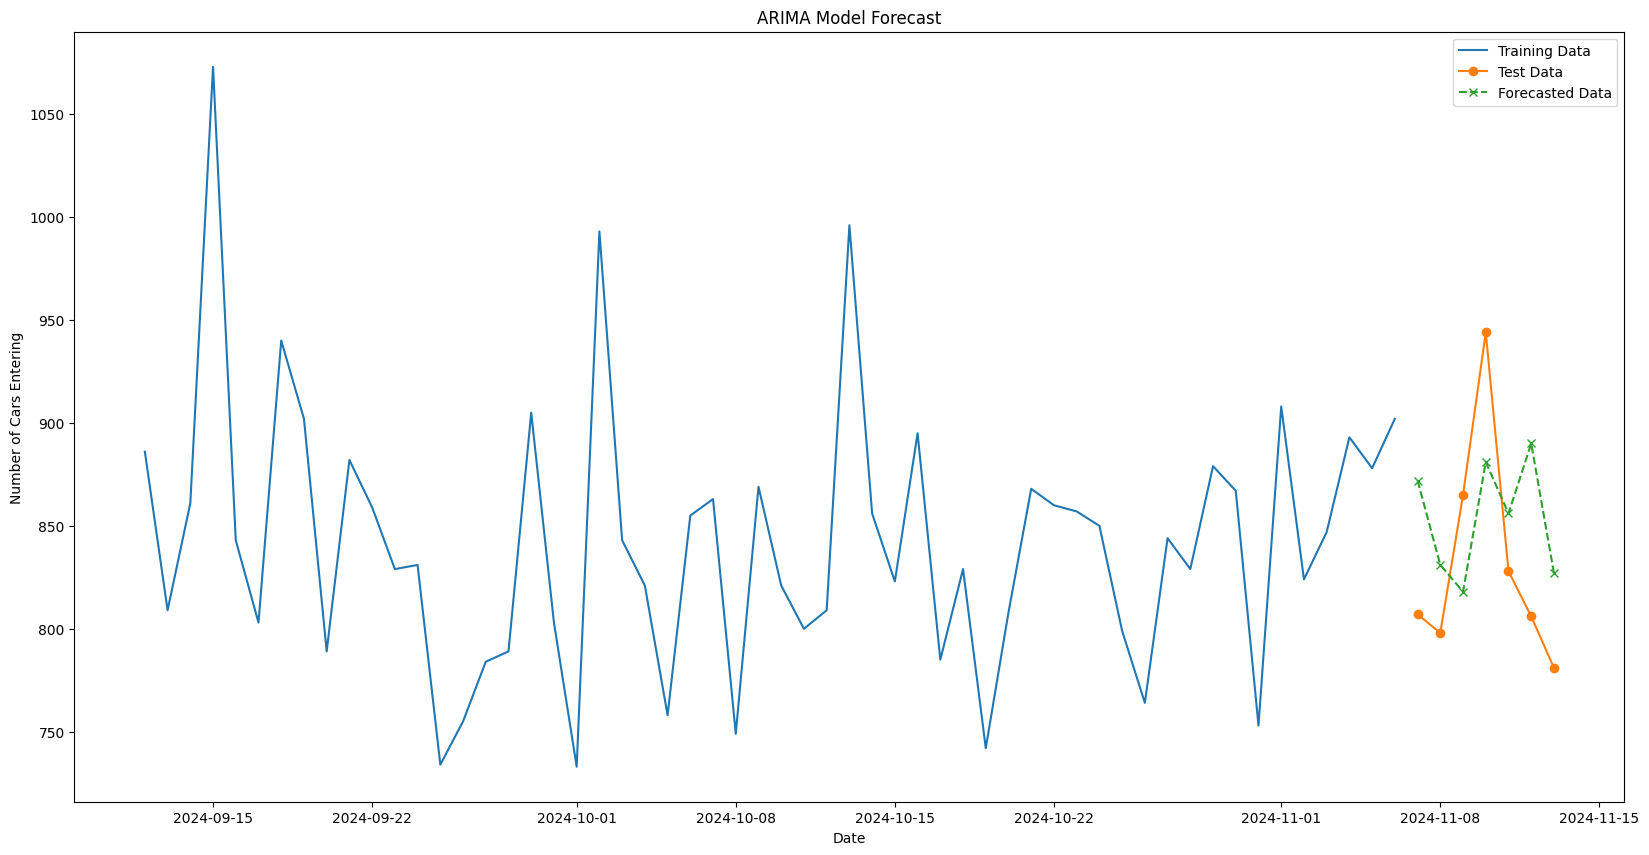

In [9]:
# Forecasting the test data

forecast = np.floor(forecaster.predict(fh=[1, 2, 3, 4, 5, 6, 7]))

# print(test_data.shape[0])
print(forecast)

# print(test_data['number_of_cars_entering'])

# Plotting the training data, test data, and forecasted data
plt.figure(figsize=(20, 10))
plt.plot(train_data['timestamp'], train_data['number_of_cars_entering'], label='Training Data')
plt.plot(test_data['timestamp'], test_data['number_of_cars_entering'], label='Test Data',marker = 'o')
plt.plot(test_data['timestamp'], forecast, label='Forecasted Data', linestyle='--',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Number of Cars Entering')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()






In [10]:
# Calculating the error metrics
MASE = mean_absolute_scaled_error(y_train=train_data['number_of_cars_entering'],y_true=test_data['number_of_cars_entering'], y_pred=forecast)
MAPE = mean_absolute_percentage_error(test_data['number_of_cars_entering'], forecast)

print('Mean Absolute Scaled Error:', MASE)
print('Mean Absolute Percentage Error:', MAPE)

Mean Absolute Scaled Error: 0.733600583090379
Mean Absolute Percentage Error: 6.284354228412201
